# Hafta 11 - MNIST ve PCA Analizi

Bu notebook, MNIST handwritten digit veri setini `hafta11/` klasoru altinda indirir, veriyi inceler ve `sklearn.decomposition.PCA` ile boyut azaltma analizi yapar.

Hedefler:
- MNIST veri setini indirip yerel klasore kaydetmek,
- Ornek rakam goruntulerini gormek,
- PCA ile aciklanan varyans oranini incelemek,
- 2 boyutlu PCA goruntusu uretmek,
- PCA ile azaltilmis ozellikler uzerinde basit bir `sklearn` modeli calistirmak.

Not:
- Veri ilk calistirmada indirilecek ve `hafta11/mnist_784.npz` olarak kaydedilecektir.
- Bu sayede sonraki calistirmalar hizli olur.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

DATA_DIR = Path("hafta11")
CACHE_FILE = DATA_DIR / "mnist_784.npz"
OPENML_CACHE = DATA_DIR / "openml_cache"
DATA_DIR.mkdir(exist_ok=True)
OPENML_CACHE.mkdir(exist_ok=True)

print(f"Veri klasoru: {DATA_DIR.resolve()}")
print(f"Onbellek dosyasi: {CACHE_FILE.resolve()}")

Veri klasoru: /home/onc/workspace/dersler/2526/ileri_programlama/hafta11
Onbellek dosyasi: /home/onc/workspace/dersler/2526/ileri_programlama/hafta11/mnist_784.npz


## 1. MNIST veri setini indirme

Aşağıdaki hücre veri setini internetten indirir. Eğer yerel önbellekte dosya varsa doğrudan onu kullanır.

MNIST:
- 70.000 adet 28x28 gri tonlamali rakam goruntusu,
- 60.000 egitim ve 10.000 test ornegi,
- Her goruntu 784 piksellik vektore cevrilerek PCA'ye hazirlanir.

In [2]:
if CACHE_FILE.exists():
    cached = np.load(CACHE_FILE)
    X = cached["X"]
    y = cached["y"]
    print("Veri onbellekten yuklendi.")
else:
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.astype(np.float32) / 255.0
    y = mnist.target.astype(np.int64)
    np.savez_compressed(CACHE_FILE, X=X, y=y)
    print("Veri indirildi ve onbellege kaydedildi.")

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("Siniflar:", np.unique(y))

Veri indirildi ve onbellege kaydedildi.
X boyutu: (70000, 784)
y boyutu: (70000,)
Siniflar: [0 1 2 3 4 5 6 7 8 9]


## 2. Veri setine hızlı bakış

İlk olarak birkaç örnek rakamı çizelim ve sınıf dağılımını kontrol edelim.

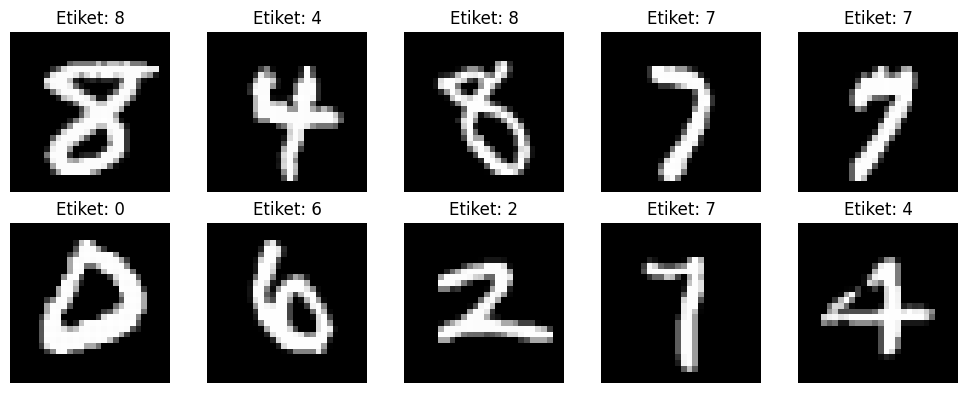

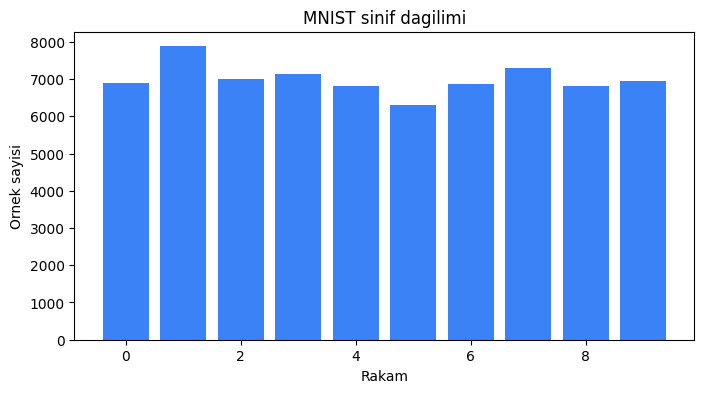

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
indices = np.random.choice(len(X), size=10, replace=False)
for axis, idx in zip(axes.ravel(), indices):
    axis.imshow(X[idx].reshape(28, 28), cmap="gray")
    axis.set_title(f"Etiket: {y[idx]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

counts = np.bincount(y)
plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(counts)), counts, color="#3b82f6")
plt.title("MNIST sinif dagilimi")
plt.xlabel("Rakam")
plt.ylabel("Ornek sayisi")
plt.show()

## 3. PCA ile boyut azaltma

PCA, veri icindeki en yuksek varyansi tasiyan eksenleri bulur. Burada amaç 784 boyutlu piksel uzayini daha kucuk bir uzaya indirip bilgiyi ne kadar korudugumuzu gormektir.

Hesaplama maliyetini kontrol etmek icin egitim/ test bolunmesi yapip PCA'yi sadece egitim verisinde ogretecegiz.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=20000,
    test_size=5000,
    random_state=42,
    stratify=y,
)

pca_full = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_train_pca = pca_full.fit_transform(X_train)
X_test_pca = pca_full.transform(X_test)

print("Egitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)
print("PCA sonrasi boyut:", X_train_pca.shape)
print("95% varyans icin gereken bileşen sayisi:", pca_full.n_components_)
print("Toplam aciklanan varyans orani:", pca_full.explained_variance_ratio_.sum())

Egitim veri boyutu: (20000, 784)
Test veri boyutu: (5000, 784)
PCA sonrasi boyut: (20000, 153)
95% varyans icin gereken bileşen sayisi: 153
Toplam aciklanan varyans orani: 0.95032287


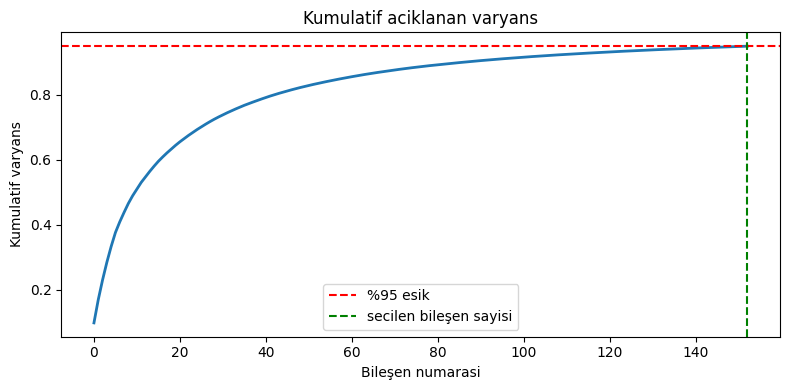

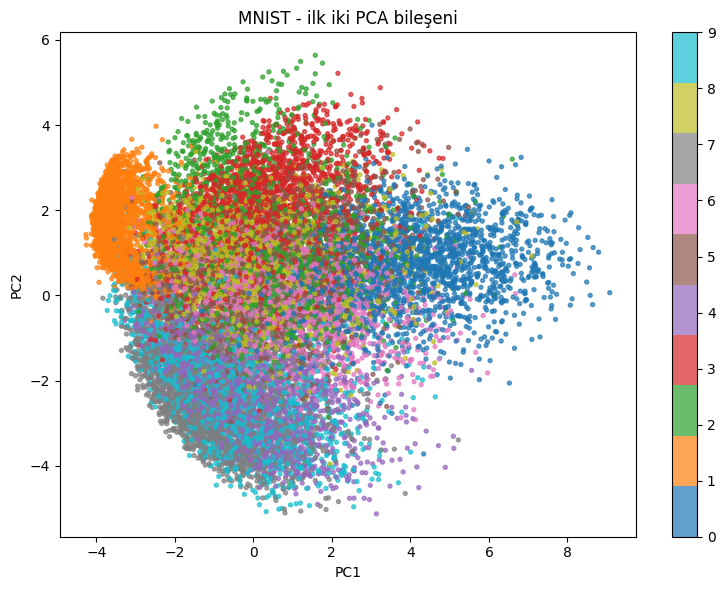

In [8]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(0.95, color="red", linestyle="--", label="%95 esik")
plt.axvline(pca_full.n_components_ - 1, color="green", linestyle="--", label="secilen bileşen sayisi")
plt.title("Kumulatif aciklanan varyans")
plt.xlabel("Bileşen numarasi")
plt.ylabel("Kumulatif varyans")
plt.legend()
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    s=8,
    cmap="tab10",
    alpha=0.7,
)
plt.title("MNIST - ilk iki PCA bileşeni")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, ticks=range(10))
plt.tight_layout()
plt.show()

## 4. PCA uzerinde basit sklearn modeli

PCA'nin siniflandirma performansina etkisini görmek icin, azaltilmis ozelliklerle lojistik regresyon calistiralim.

In [9]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),
])

model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

print("Test dogrulugu:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test dogrulugu: 0.9176
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       493
           1       0.95      0.98      0.96       563
           2       0.91      0.89      0.90       499
           3       0.91      0.89      0.90       510
           4       0.93      0.94      0.94       487
           5       0.87      0.86      0.87       451
           6       0.93      0.93      0.93       491
           7       0.92      0.93      0.93       521
           8       0.87      0.89      0.88       488
           9       0.91      0.90      0.90       497

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



## 5. Kisa yorum

- PCA, 784 boyutlu goruntuleri cok daha kucuk bir uzaya indirgerken verinin buyuk kismini korur.
- Ilk iki PCA bileşeni, rakamlar arasindaki kaba ayrimi goruntulemek icin yeterlidir.
- PCA ile boyut azalttiktan sonra basit bir sklearn modeli ile tatmin edici bir basari elde edilebilir.

Isterseniz bir sonraki adimda PCA yerine `IncrementalPCA` ya da PCA + `KNeighborsClassifier` karsilastirmasi da eklenebilir.